# Matemáticas aplicadas. Practica Final

#### Samuel Acosta Aristizábal - 1000900513
#### Manuela Caro Villada - 1000124254
#### Jeronimo Velasquez Escobar - 1000116682

In [25]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


### Objetivo
Integrar herramientas de álgebra lineal multivariada, métricas de distancia y optimización convexa para
transformar datos no estructurados (imágenes) en un espacio latente de baja dimensión, detectar valores atípicos mediante matrices de covarianza, y entrenar matemáticamente un clasificador binario construyendo sus propios algoritmos de descenso de gradiente.

In [26]:
# Datos a utilizar en el examen
from sklearn.datasets import fetch_olivetti_faces as olivetti
Original_data = olivetti()

data.keys(): dict_keys(['data', 'images', 'target', 'DESCR'])
data['images'].shape: (400, 64, 64)
data['target'].shape: (400,)
data['images'][0].shape: (64, 64)
data['data']: (400, 4096)


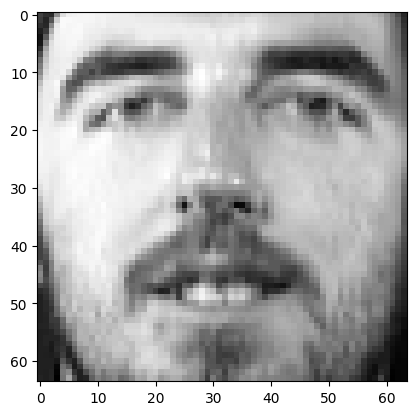

In [27]:
# Visualizamos la data
print("data.keys():", Original_data.keys())
print("data['images'].shape:", Original_data['images'].shape)
print("data['target'].shape:", Original_data['target'].shape)
print("data['images'][0].shape:", Original_data['images'][0].shape)
print("data['data']:", Original_data['data'].shape)
# Visualizamos una imagen
plt.imshow(Original_data['images'][100], cmap='gray')

In [28]:
Original_data['data'].shape # Esta es la data ya aplanana dimensiones 400 x 4096
datos = Original_data['data'].copy() # Hacemos una copia de la data para no modificar la original
datos.shape

(400, 4096)

Ancla: [0.7231405  0.7231405  0.72727275 ... 0.22727273 0.21900827 0.21900827]


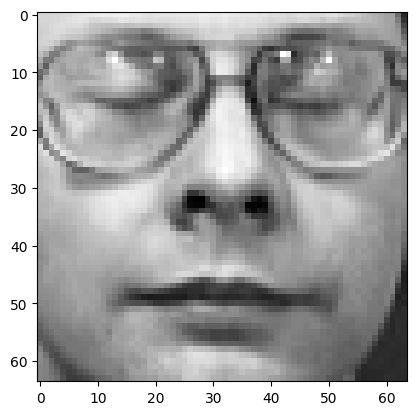

In [29]:
# Tarea 1 punto a)

# Se Selecciona el ancla

ancla = datos[38]
print("Ancla:", ancla)

# Se calcula la distancia euclidiana entre el ancla y cada una de las otras imágenes, con operaciones basicas
L2 = np.sqrt(np.sum((datos - ancla) ** 2, axis=1))
plt.imshow(ancla.reshape(64, 64), cmap='gray')


In [30]:
# Se calcula la similitud coseno entre el ancla y cada una de las otras imágenes, con operaciones basicas
cosine_similarity = (np.sum(datos * ancla, axis=1) / (np.linalg.norm(datos, axis=1) * np.linalg.norm(ancla)))

In [31]:
# Seleccionamos las 3 imágenes más similares al ancla según la distancia euclidiana
indices_euclidianos = np.argsort(L2)[1:4] # Excluimos el primer elemento que es el ancla
print("Índices de las 3 imágenes más similares según distancia euclidiana:", indices_euclidianos)
indices_por_coseno = np.argsort(cosine_similarity)[-4:-1] # Excluimos el primer elemento que es el ancla
print("Índices de las 3 imágenes más similares según similitud coseno:", indices_por_coseno)

Índices de las 3 imágenes más similares según distancia euclidiana: [ 31 208 149]
Índices de las 3 imágenes más similares según similitud coseno: [34 31 33]


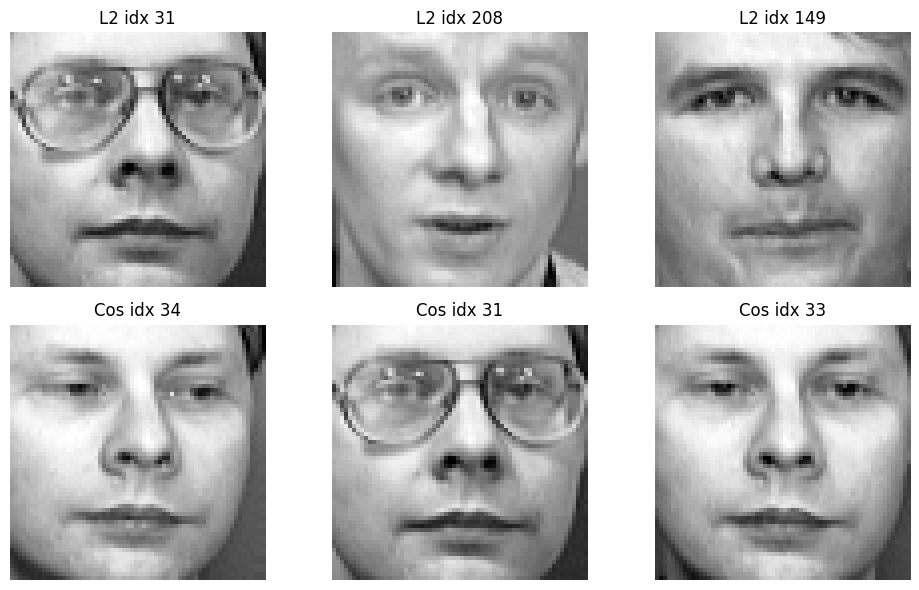

In [32]:
# Visualizamos las imagenes relacionadas al ancla por distancia euclidiana
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# Primera fila: L2
for i, idx in enumerate(indices_euclidianos):
    axes[0, i].imshow(datos[idx].reshape(64, 64), cmap='gray')
    axes[0, i].set_title(f"L2 idx {idx}")
    axes[0, i].axis('off')

# Segunda fila: Coseno
for i, idx in enumerate(indices_por_coseno):
    axes[1, i].imshow(datos[idx].reshape(64, 64), cmap='gray')
    axes[1, i].set_title(f"Cos idx {idx}")
    axes[1, i].axis('off')



plt.tight_layout()
plt.show()

#### Tarea 1 

D) Discusion. No, las imagenes mas cercanas no siempre provienen de la misma persona, realizamos la prueba con distintas anclas y en algunos casos ambas distancias nos mostraban los mismos vectores mas cercanos y en otras los vectores mas cercanos no se correspondian como se puede observar en la imagen anterior. Podemos nuentra ancla es el numero 38 lo que nos dice que esta persona va ser la misma si los indices de los vectores van de entre 30 a el 39. Con la distancia euclidiana solamente uno de los vectores mas proximos es el que aparece, este siendo especificamente el veector con indice 31. Por otro lado el resto de imagenes no pertenece a la misma persona. Estos errores tan grandees no se presentan en la distancia de el coseno

¿Por qué la distancia Euclidiana directa sobre píxeles es estadísticamente frágil si la persona mueve ligeramentela cabeza o hay un cambio global en la iluminación?

La razon es porque trata cada píxel como una variable independiente y suma las diferencias cuadráticas en las 4096 dimensiones. Pequeños desplazamientos del rostro o cambios globales de iluminación alteran simultáneamente muchos píxeles, lo que incrementa artificialmente la distancia aun cuando la identidad visual sea la misma. En espacios de alta dimensión, estas pequeñas variaciones se acumulan y hacen que la métrica sea estadísticamente frágil, ya que no considera la correlación estructural entre píxeles ni es invariante a transformaciones globales.

### Tarea Numero 2

In [33]:
# Centrar los datos

datos_centrados = datos - np.mean(datos, axis=0)
datos_centrados # Verificamos que la media de cada columna sea 0 o cercano a 0

array([[-0.09021699, -0.06646687, -0.05892554, ..., -0.1685228 ,
        -0.15248989, -0.15342984],
       [ 0.05441111,  0.03683892,  0.0361158 , ..., -0.1685228 ,
        -0.16075435, -0.15756208],
       [-0.08195254, -0.033409  ,  0.01545465, ..., -0.1809195 ,
        -0.16488658, -0.15756208],
       ...,
       [ 0.09986565,  0.09882241,  0.13115713, ..., -0.14372942,
        -0.16488658, -0.120372  ],
       [-0.18525833, -0.21522719, -0.25727263, ...,  0.2529648 ,
         0.27726215,  0.29285112],
       [ 0.11639455,  0.02857447, -0.19528916, ...,  0.03808877,
         0.04172498,  0.07384288]], shape=(400, 4096), dtype=float32)

In [34]:
# Calculamos la SVD de los datos centrados con la función de numpy
U, S, VT = np.linalg.svd(datos_centrados, full_matrices=False)

In [35]:
# Redimensionamos los autovectores para visualizar las componentes principales como imágenes
VT[i].reshape(64,64)

array([[ 1.35690800e-03, -3.25796980e-04, -1.97989022e-04, ...,
        -1.53232701e-02, -1.42423194e-02, -1.23441610e-02],
       [-1.37596927e-03, -4.13334649e-03, -2.79704598e-03, ...,
        -1.85812749e-02, -1.69116054e-02, -1.52588375e-02],
       [-5.06049907e-03, -6.63175480e-03, -4.92102187e-03, ...,
        -2.05908976e-02, -2.08347160e-02, -1.80020630e-02],
       ...,
       [ 1.88907376e-03,  1.94925163e-03, -1.41839428e-06, ...,
        -1.45552428e-02, -1.48671269e-02, -1.30803268e-02],
       [ 1.06227573e-03,  6.28076959e-04, -5.02781813e-06, ...,
        -1.47863040e-02, -1.38062909e-02, -1.32958014e-02],
       [ 1.11527811e-03,  3.17762751e-04, -4.38066403e-04, ...,
        -1.54136522e-02, -1.37097845e-02, -1.18834134e-02]],
      shape=(64, 64), dtype=float32)

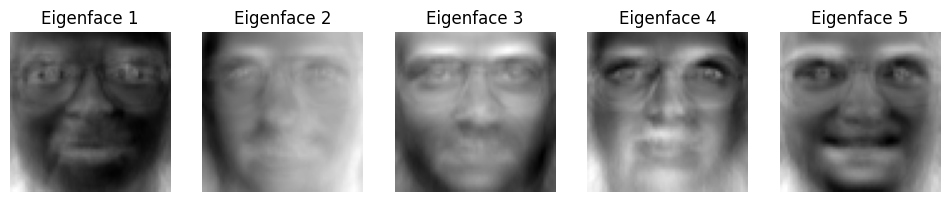

In [36]:
fig, axes = plt.subplots(1, 5, figsize=(12,4))

for i in range(5):
    axes[i].imshow(VT[i].reshape(64,64), cmap='gray')
    axes[i].set_title(f"Eigenface {i+1}")
    axes[i].axis('off')

plt.show()

#### Que es un eigenface?
Un eigenface corresponde a un vector singular derecho obtenido mediante la SVD de la matriz de imágenes centrada. Cada uno de estos vectores pertenece al espacio de píxeles y, al reorganizarse en una matriz de 64×64, puede visualizarse como una imagen. Estos patrones representan las direcciones de mayor variación en el conjunto de rostros. Los primeros eigenfaces suelen capturar características globales como patrones de iluminación, contornos del rostro y la ubicación general de ojos, nariz y boca, ya que estas son las fuentes principales de variabilidad en el dataset.

Y si observamos los eigenfaces anteriores, nos damos cuenta quee estan resaltando mucho la iluminacion de las caras, y el contorno de los ojos, ademas nos damos cuenta que algo que no se resalta en ninguna de elas imagenes son las cejas y la razon de estos e debe a que estas no varian practicamente nada entre fotos, por lo que no se encuentran en los primeros eigenfaces.

In [37]:
# Seguimos por el punto d, tomamos los primeros 50 autovectores y proyectamos los datos centrados sobre estos autovectores para obtener las componentes principales de los datos
V_50 = VT[:50].T
# Lo proyectamos
Z = datos_centrados @ V_50

Z.shape
print(Z[0])

[-6.4326124  -0.70366883 -1.4300224   1.2785368  -2.5643935   0.95060307
 -2.081762    2.9379458  -0.3738861   0.24311721 -1.3543113   1.1725689
 -0.39208186  0.35820484 -0.7542007   0.27037773 -0.51470166  0.5964256
 -0.15579087  0.28312027 -0.13553068  0.73604107 -0.12472099  0.42592824
 -0.49944097  0.5080134  -0.71291596  0.14960283 -0.02979663  0.5985956
  0.51039374 -0.34161046  0.08967796 -0.8147292  -0.13537422 -0.18435672
  0.31189197  0.5696769  -0.39455423 -0.5040104   0.27508992 -0.18206765
  0.01745617 -0.5627584   0.47822905 -0.27928114  0.30580842 -0.27920246
  0.25388718 -0.598417  ]


#### ¿Qué hicimos?

Proyectamos las imágenes centradas sobre los primeros 50 eigenfaces obtenidos mediante la SVD. 
Estos eigenfaces corresponden a las direcciones de mayor varianza en el conjunto de datos, por 
lo que capturan las variaciones más importantes presentes en los rostros.

Al realizar esta proyección reducimos la dimensionalidad del problema, pasando de representar 
cada imagen con 4096 píxeles a describirla mediante solo 50 coeficientes en el espacio latente. 
Cada uno de estos coeficientes indica cuánto contribuye un eigenface específico en la 
reconstrucción del rostro.

Esta representación compacta conserva la información más relevante de las imágenes y facilita 
tareas posteriores como reconocimiento facial, compresión de imágenes o detección de anomalías.

### Tarea Numero 3

In [38]:
#Imagen Intrusa
intruder = np.concatenate([
    np.ones(2048),
    np.zeros(2048)
])
intruder.shape
# Centramos la imagen intrusa
intruder_centered = intruder - np.mean(datos, axis=0)
# Proyectamos la imagen intrusa sobre los primeros 50 autovectores
intruder_projection = intruder_centered @ V_50
intruder_projection.shape
# La añadimos a la matriz de componentes principales
Z_augmented = np.vstack([Z, intruder_projection])
Z_augmented.shape


(401, 50)

In [39]:
# Ahora calculamos la distancia de mahalanobis entre la imagen intrusa y las otras imágenes en el espacio de las componentes principales
mu_z = np.mean(Z, axis=0)
cov_z = np.cov(Z, rowvar=False)
cov_inv = np.linalg.inv(cov_z)

distancias_mahalanobis = []

for z in Z_augmented:
    diff = z - mu_z
    d = np.sqrt(diff @ cov_inv @ diff)
    distancias_mahalanobis.append(d)

distancias_mahalanobis = np.array(distancias_mahalanobis)

np.argmax(distancias_mahalanobis) # Debe ser eel ultimo debido a que ees la imagen intrusa

np.int64(400)

In [40]:

anomaly_index = np.argmax(distancias_mahalanobis)
print(anomaly_index)

400


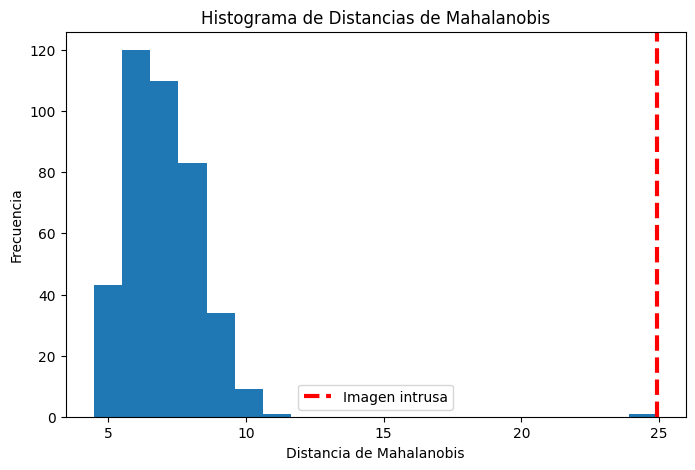

In [43]:
# distancias_mahalanobis -> array con todas las distancias
# indice_intruso -> índice donde agregaste la imagen intrusa

dist_intruso = distancias_mahalanobis[anomaly_index]

plt.figure(figsize=(8,5))

# Histograma de todas las distancias
plt.hist(distancias_mahalanobis, bins=20)

# Línea vertical roja para la imagen intrusa
plt.axvline(dist_intruso, color='red', linestyle='--', linewidth=3, label="Imagen intrusa")

plt.title("Histograma de Distancias de Mahalanobis")
plt.xlabel("Distancia de Mahalanobis")
plt.ylabel("Frecuencia")

plt.legend()

plt.show()

Se calculó la distancia de Mahalanobis para cada imagen del conjunto. 
Posteriormente se graficó un histograma de dichas distancias y se marcó 
la imagen intrusa con una línea vertical.

La imagen intrusa presenta una distancia significativamente mayor que 
las demás, lo cual indica que se encuentra fuera de la distribución de 
los datos originales, confirmando su carácter de outlier.

#### Discusión

En el espacio latente obtenido mediante SVD, las características (componentes principales) son ortogonales entre sí. Esto significa que cada componente captura una dirección independiente de variación dentro del conjunto de datos.

Si utilizáramos la distancia Euclidiana, todas las dimensiones del espacio tendrían el mismo peso en el cálculo de la distancia. Sin embargo, en la representación obtenida mediante SVD, cada componente principal posee una varianza distinta. Las primeras componentes suelen capturar mucha más varianza que las últimas.

La distancia de Mahalanobis corrige este problema al incorporar la matriz de covarianza Σ del conjunto de datos:

$$
d_M(x) = \sqrt{(x - \mu)^T \Sigma^{-1} (x - \mu)}
$$

Al utilizar Σ⁻¹, la métrica ajusta automáticamente la contribución de cada dimensión según su varianza. Las direcciones con alta varianza tienen menor peso relativo, mientras que las direcciones con baja varianza se vuelven más sensibles a desviaciones.

Debido a que en el espacio de componentes principales la matriz de covarianza es diagonal (por la ortogonalidad de las componentes), Mahalanobis equivale a escalar cada dimensión por su varianza correspondiente. Esto permite detectar desviaciones inusuales respecto a la distribución real de los datos.

Por esta razón, la distancia de Mahalanobis es superior a la distancia Euclidiana para detectar outliers, ya que considera la estructura estadística del espacio latente y no trata todas las direcciones como igualmente importantes.